# Disease Prediction and Progression System

This notebook implements a machine learning system for disease prediction based on symptoms and disease progression modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import pickle
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


## Data Loading

Load the datasets for classification and regression.

In [2]:
# Load classification dataset
file_path_classification = 'healthcare-chatbot/Data/Training.csv'

df_classification = pd.read_csv(file_path_classification)

# Clean up any 'Unnamed: X' columns
unnamed_cols = [col for col in df_classification.columns if 'Unnamed:' in col and df_classification[col].isnull().all()]
if unnamed_cols:
    df_classification.drop(columns=unnamed_cols, inplace=True)

# Rename 'prognosis' to 'disease'
if 'prognosis' in df_classification.columns:
    df_classification.rename(columns={'prognosis': 'disease'}, inplace=True)

# Ensure 'disease' is string
df_classification['disease'] = df_classification['disease'].astype(str).fillna('Unknown')

print(f"Classification dataset loaded. Shape: {df_classification.shape}")
print(df_classification.head())

Classification dataset loaded. Shape: (4920, 133)
   itching  skin_rash  nodal_skin_eruptions  continuous_sneezing  shivering  \
0        1          1                     1                    0          0   
1        0          1                     1                    0          0   
2        1          0                     1                    0          0   
3        1          1                     0                    0          0   
4        1          1                     1                    0          0   

   chills  joint_pain  stomach_pain  acidity  ulcers_on_tongue  ...  \
0       0           0             0        0                 0  ...   
1       0           0             0        0                 0  ...   
2       0           0             0        0                 0  ...   
3       0           0             0        0                 0  ...   
4       0           0             0        0                 0  ...   

   blackheads  scurring  skin_peeling  silver_li

In [3]:
# Create synthetic regression dataset for disease progression
np.random.seed(42)
n_samples = 1000

progression_data = {
    'Age': np.random.randint(20, 80, n_samples),
    'Gender': np.random.choice([0, 1], n_samples),  # 0: Female, 1: Male
    'Disease': np.random.choice(df_classification['disease'].unique(), n_samples),
    'MedicalHistory': np.random.choice([0, 1, 2], n_samples),  # Encoded
    'Lifestyle': np.random.choice([0, 1, 2], n_samples),  # Encoded
    'BiomarkerScore': np.random.uniform(0, 1, n_samples),
    'MedicationDose': np.random.uniform(0, 100, n_samples),
    'HeartRate': np.random.randint(60, 100, n_samples),
    'BloodPressure_Systolic': np.random.randint(90, 180, n_samples),
    'BloodPressure_Diastolic': np.random.randint(60, 120, n_samples),
    'Cholesterol': np.random.randint(150, 300, n_samples),
    'BMI': np.random.uniform(18, 35, n_samples),
    'SleepHours': np.random.uniform(4, 10, n_samples),
    'StepsPerDay': np.random.randint(2000, 15000, n_samples),
    'MedicationAdherence': np.random.choice([0, 1], n_samples),
    'StressLevel': np.random.randint(1, 10, n_samples),
    'CognitiveScore': np.random.randint(50, 100, n_samples),
    'MoodScore': np.random.randint(1, 10, n_samples),
    'Smoker': np.random.choice([0, 1], n_samples),
    'AlcoholUse': np.random.choice([0, 1, 2], n_samples),
    'SupportSystem': np.random.choice([0, 1, 2], n_samples),
    'HasCaregiver': np.random.choice([0, 1], n_samples),
    'EmploymentStatus': np.random.choice([0, 1, 2], n_samples),
    'Stage': np.random.uniform(1, 5, n_samples)  # Progression stage
}

df_progression = pd.DataFrame(progression_data)
print(f"Regression dataset created. Shape: {df_progression.shape}")
print(df_progression.head())

Regression dataset created. Shape: (1000, 24)
   Age  Gender               Disease  MedicalHistory  Lifestyle  \
0   58       1               Allergy               2          2   
1   71       1       Osteoarthristis               2          1   
2   48       0          Hypoglycemia               1          1   
3   34       1          Heart attack               0          2   
4   62       0  Cervical spondylosis               0          2   

   BiomarkerScore  MedicationDose  HeartRate  BloodPressure_Systolic  \
0        0.787387       72.893920         72                     120   
1        0.454345       77.982088         74                     115   
2        0.630247       11.821862         66                     118   
3        0.248384        0.003072         99                     156   
4        0.705461       71.213705         87                     167   

   BloodPressure_Diastolic  ...  MedicationAdherence  StressLevel  \
0                      113  ...                  

## Preprocessing

Prepare the data for modeling.

In [4]:
# Classification preprocessing
X_classification = df_classification.drop('disease', axis=1)
y_classification = df_classification['disease']

# Encode target
le_classification = LabelEncoder()
y_classification_encoded = le_classification.fit_transform(y_classification)

# Train-test split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_classification, y_classification_encoded, test_size=0.2, random_state=42, stratify=y_classification_encoded
)

print(f"Classification - X_train: {X_train_clf.shape}, X_test: {X_test_clf.shape}")

Classification - X_train: (3936, 132), X_test: (984, 132)


In [5]:
# Regression preprocessing
# Encode categorical features
categorical_cols = ['Disease', 'MedicalHistory', 'Lifestyle', 'MedicationAdherence', 'Smoker', 'AlcoholUse', 'SupportSystem', 'HasCaregiver', 'EmploymentStatus']
le_reg = {}
for col in categorical_cols:
    le_reg[col] = LabelEncoder()
    df_progression[col] = le_reg[col].fit_transform(df_progression[col])

X_progression = df_progression.drop('Stage', axis=1)
y_progression = df_progression['Stage']

# Scale features
scaler = StandardScaler()
X_progression_scaled = scaler.fit_transform(X_progression)

# Train-test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_progression_scaled, y_progression, test_size=0.2, random_state=42
)

print(f"Regression - X_train: {X_train_reg.shape}, X_test: {X_test_reg.shape}")

Regression - X_train: (800, 23), X_test: (200, 23)


## Training

Train the classification and regression models.

In [6]:
# Train classification models
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_clf, y_train_clf)
print("Decision Tree trained.")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_clf, y_train_clf)
print("Random Forest trained.")

# Select best model
y_pred_dt = dt_model.predict(X_test_clf)
y_pred_rf = rf_model.predict(X_test_clf)

acc_dt = accuracy_score(y_test_clf, y_pred_dt)
acc_rf = accuracy_score(y_test_clf, y_pred_rf)

best_model_clf = rf_model if acc_rf >= acc_dt else dt_model
print(f"Best classification model: {type(best_model_clf).__name__}")

Decision Tree trained.
Random Forest trained.
Best classification model: RandomForestClassifier


In [7]:
# Train regression model
reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
reg_model.fit(X_train_reg, y_train_reg)
print("Random Forest Regressor trained.")

Random Forest Regressor trained.


## Evaluation

Evaluate the models.

Classification Report:
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        24
                                   AIDS       1.00      1.00      1.00        24
                                   Acne       1.00      1.00      1.00        24
                    Alcoholic hepatitis       1.00      1.00      1.00        24
                                Allergy       1.00      1.00      1.00        24
                              Arthritis       1.00      1.00      1.00        24
                       Bronchial Asthma       1.00      1.00      1.00        24
                   Cervical spondylosis       1.00      1.00      1.00        24
                            Chicken pox       1.00      1.00      1.00        24
                    Chronic cholestasis       1.00      1.00      1.00        24
                            Common Cold       1.00      1.00      1.00        24
    

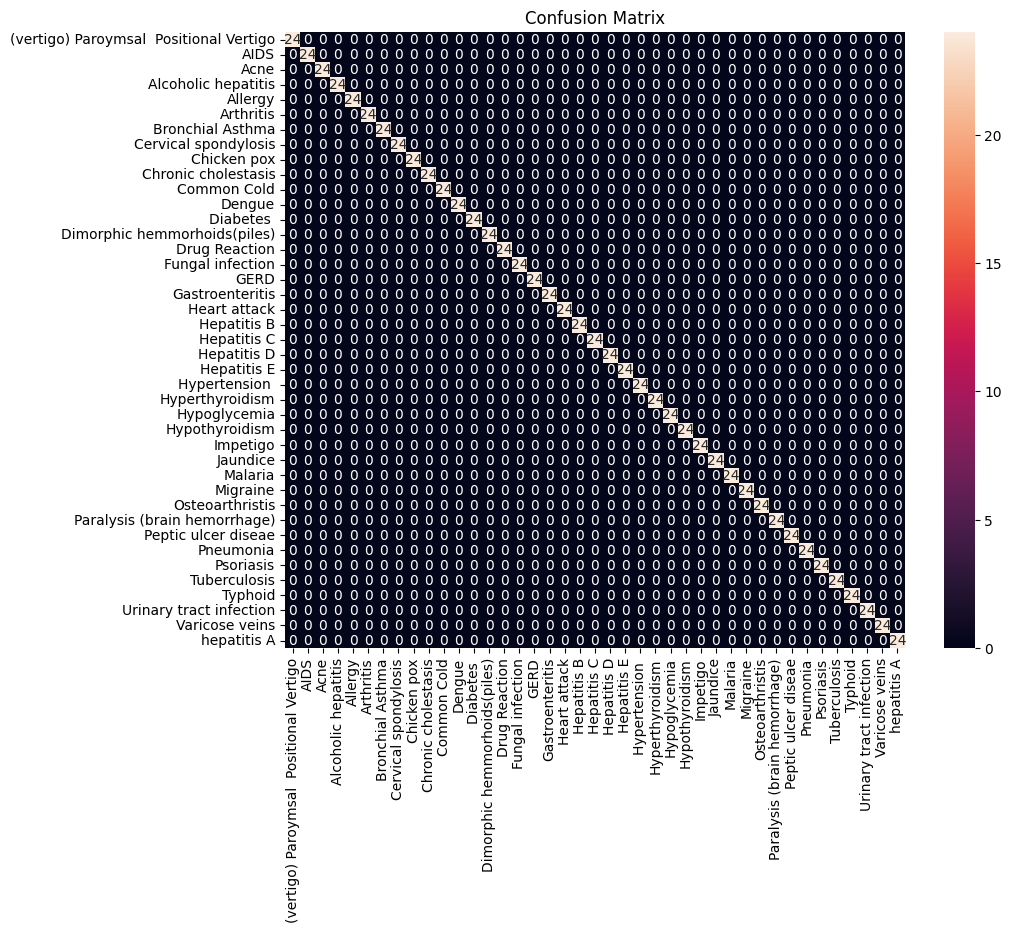

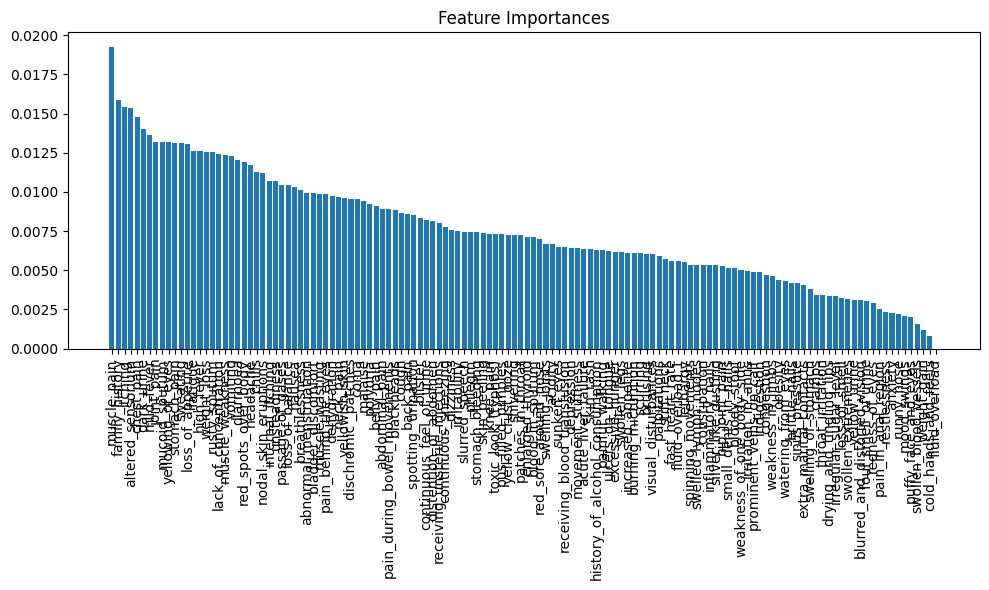

In [8]:
# Evaluate classification
y_pred_clf = best_model_clf.predict(X_test_clf)

print("Classification Report:")
print(classification_report(y_test_clf, y_pred_clf, target_names=le_classification.classes_))

print("Confusion Matrix:")
cm = confusion_matrix(y_test_clf, y_pred_clf)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le_classification.classes_, yticklabels=le_classification.classes_)
plt.title('Confusion Matrix')
plt.show()

# Feature importance for Random Forest
if isinstance(best_model_clf, RandomForestClassifier):
    importances = best_model_clf.feature_importances_
    indices = np.argsort(importances)[::-1]
    plt.figure(figsize=(10, 6))
    plt.title('Feature Importances')
    plt.bar(range(X_train_clf.shape[1]), importances[indices], align='center')
    plt.xticks(range(X_train_clf.shape[1]), X_train_clf.columns[indices], rotation=90)
    plt.tight_layout()
    plt.show()

RMSE: 1.1549
MAE: 0.9888
R²: -0.0001


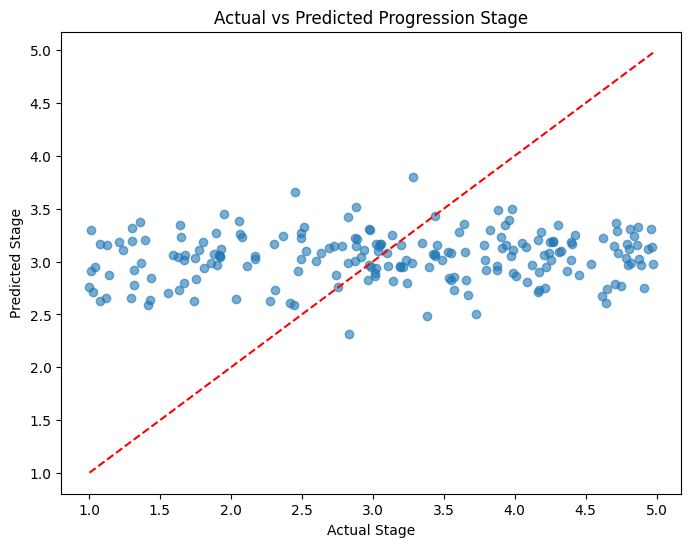

In [9]:
# Evaluate regression
y_pred_reg = reg_model.predict(X_test_reg)

rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
mae = mean_absolute_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
plt.xlabel('Actual Stage')
plt.ylabel('Predicted Stage')
plt.title('Actual vs Predicted Progression Stage')
plt.show()

## Save Models

Save the trained models.

In [10]:
# Save models
with open('model.pkl', 'wb') as f:
    pickle.dump(best_model_clf, f)

with open('reg_model.pkl', 'wb') as f:
    pickle.dump(reg_model, f)

with open('le_classification.pkl', 'wb') as f:
    pickle.dump(le_classification, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Models and preprocessors saved.")

Models and preprocessors saved.


## Prediction

Functions for making predictions.

In [11]:
def predict_disease(symptoms):
    """
    Predict disease from symptoms.
    symptoms: list of symptom names present.
    """
    input_vector = np.zeros(X_train_clf.shape[1])
    for symptom in symptoms:
        if symptom in X_train_clf.columns:
            idx = X_train_clf.columns.get_loc(symptom)
            input_vector[idx] = 1
    pred = best_model_clf.predict([input_vector])
    disease = le_classification.inverse_transform(pred)[0]
    return disease

def predict_progression(disease):
    """
    Predict progression stage for a disease.
    Use default values for other features.
    """
    # Default values
    default_input = {
        'Age': 50,
        'Gender': 1,
        'Disease': disease,
        'MedicalHistory': 1,
        'Lifestyle': 1,
        'BiomarkerScore': 0.5,
        'MedicationDose': 50,
        'HeartRate': 75,
        'BloodPressure_Systolic': 130,
        'BloodPressure_Diastolic': 85,
        'Cholesterol': 200,
        'BMI': 25,
        'SleepHours': 7,
        'StepsPerDay': 8000,
        'MedicationAdherence': 1,
        'StressLevel': 5,
        'CognitiveScore': 75,
        'MoodScore': 5,
        'Smoker': 0,
        'AlcoholUse': 1,
        'SupportSystem': 1,
        'HasCaregiver': 0,
        'EmploymentStatus': 1
    }
    
    # Encode disease
    if disease in le_reg['Disease'].classes_:
        default_input['Disease'] = le_reg['Disease'].transform([disease])[0]
    else:
        default_input['Disease'] = 0  # Default
    
    input_df = pd.DataFrame([default_input])
    input_scaled = scaler.transform(input_df)
    stage = reg_model.predict(input_scaled)[0]
    return stage

# Example prediction
example_symptoms = ['vomiting', 'acidity']
predicted_disease = predict_disease(example_symptoms)
predicted_stage = predict_progression(predicted_disease)
print(f"Predicted Disease: {predicted_disease}")
print(f"Predicted Stage: {predicted_stage:.2f}")

Predicted Disease: GERD
Predicted Stage: 3.14
